# N2 · 特征单义性 + 真实 gpt2 SAE

> 配套 12.4-L3 · ① 玩具: 每个 SAE 特征对应哪个「当前值」(特征×值热图, 看单义)。
> ② **真实 gpt2**: 在 gpt2 激活上训 mini-SAE, 找一个特征的最大激活 token (比原始多义神经元更连贯)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import sae as S
import tiny_transformer as tt
import numpy as np, torch
import realmodels as rm
print('真实模型:', rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


## 1. 玩具: 特征 × 当前值 热图 (单义 = 每个特征专一对应一个值)

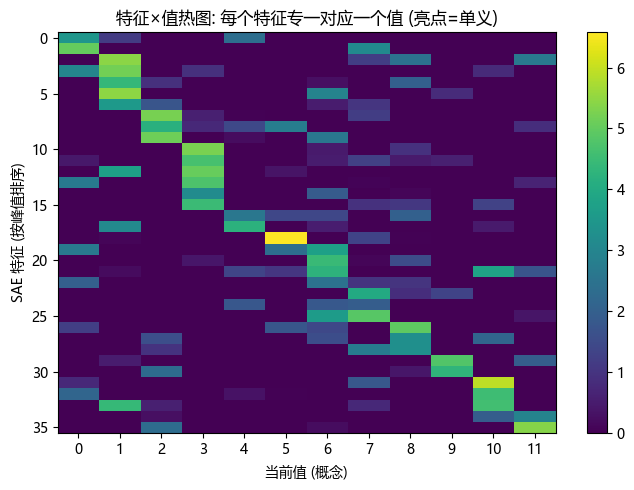

→ 每行(特征)只在某一列(值)亮 → 特征单义 (一个特征=一个概念)。这就是解叠加的样子。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(0)
Xi,Yi=tt.make_data(2000,seed=0); model=tt.build_model(); tt.train(model,Xi,Yi,epochs=800)
acts, labels = S.tiny_mlp_activations(model, tt.make_data(1500, seed=2)[0])
sae = S.build_sae(acts.shape[1], tt.V*3); S.train_sae(sae, acts, epochs=600, l1=1e-2)
codes = S.feature_codes(sae, acts)
active, _ = S.monosemanticity(codes, labels)
# 每个活跃特征在各 value 上的平均激活
M = np.zeros((len(active), tt.V))
for i, fi in enumerate(active):
    for v in range(tt.V):
        M[i, v] = codes[labels==v, fi].mean()
# 按峰值 value 排序特征, 让"对角"显现
order = np.argsort(M.argmax(1))
fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(M[order], aspect='auto', cmap='viridis')
ax.set_xlabel('当前值 (概念)'); ax.set_ylabel('SAE 特征 (按峰值排序)'); ax.set_xticks(range(tt.V))
ax.set_title('特征×值热图: 每个特征专一对应一个值 (亮点=单义)')
plt.colorbar(im); plt.tight_layout(); plt.show()
print('→ 每行(特征)只在某一列(值)亮 → 特征单义 (一个特征=一个概念)。这就是解叠加的样子。')

## 2. 真实 gpt2: 在激活上训 mini-SAE, 看一个特征的最大激活 token

In [3]:
tok, gpt2 = rm.gpt2()
if gpt2 is not None:
    CORPUS = [
        "The cat sat on the warm mat near the door.",
        "She invested money in the stock market last year.",
        "Water boils at one hundred degrees in the pot.",
        "The president signed the new law on Monday.",
        "He scored a goal in the final football match.",
        "The recipe needs two cups of white flour.",
        "Astronomers discovered a distant bright galaxy.",
        "The lawyer argued the difficult case in court.",
        "Children played happily in the green park.",
        "The loud engine roared as the car sped up fast.",
        "Doctors treated the patient in the busy hospital.",
        "The river flowed gently past the old stone bridge.",
    ]
    LAYER = 6
    X, meta = [], []
    h = gpt2.transformer.h[LAYER].mlp.act.register_forward_hook(lambda m,i,o: cap.__setitem__('a', o.detach()))
    cap = {}
    for s in CORPUS:
        ids = tok(s, return_tensors='pt')
        with torch.no_grad(): gpt2(**ids)
        a = cap['a'][0]   # (seq, 3072)
        for j,t in enumerate(ids.input_ids[0]):
            X.append(a[j].numpy()); meta.append(tok.decode([t]).strip() or '␣')
    h.remove()
    X = np.array(X, dtype=np.float32)
    print(f'gpt2 第{LAYER}层 MLP 激活 {X.shape}; 训 mini-SAE...')
    gsae = S.build_sae(X.shape[1], 512, seed=0)
    S.train_sae(gsae, X, epochs=400, l1=2e-3)
    gcodes = S.feature_codes(gsae, X)
    # 找几个"活跃且集中"的特征, 看最大激活 token
    act_count = (gcodes > 1e-3).sum(0)
    cand = np.where((act_count > 2) & (act_count < len(X)*0.3))[0]
    shown = 0
    for fi in cand[np.argsort(-gcodes[:, cand].max(0))]:
        top = np.argsort(-gcodes[:, fi])[:5]
        print(f'  SAE 特征 #{fi}: 最大激活 token = {[meta[i] for i in top]}')
        shown += 1
        if shown >= 4: break
    print('→ SAE 特征的最大激活 token 比 12.1 的原始多义神经元更"成主题" (解叠加的真实版)。')
else:
    print('无 gpt2, 跳过')

gpt2 第6层 MLP 激活 (115, 3072); 训 mini-SAE...


  SAE 特征 #351: 最大激活 token = ['one', 'at', 'in', 'pot', 'the']
  SAE 特征 #48: 最大激活 token = ['up', 'busy', 'roared', 'sped', 'bright']
  SAE 特征 #283: 最大激活 token = ['cups', 'galaxy', 'degrees', 'sat', 'the']
  SAE 特征 #130: 最大激活 token = ['as', '.', '.', 'The', 'the']
→ SAE 特征的最大激活 token 比 12.1 的原始多义神经元更"成主题" (解叠加的真实版)。


## 3. 反思 (12.4 收口)

你检视了 SAE 特征的单义性 (玩具 + 真实 gpt2)。带走:
- **最大激活样本**: 给特征贴人话标签; 玩具特征专一对应一个值, gpt2 特征成主题。
- **解叠加**: SAE 把叠加的多义激活, 变成更单义、可读的特征字典 (Anthropic 显微镜)。
- ⚠ **批判** (L4): 特征单义 ≠ 真实/模型在用; 评估 SAE 有争议; 要因果验证 (干预)。

> **M12.4 收口**: superposition→SAE 解叠加 (过完备+稀疏); 最大激活样本贴标签; 金门大桥特征; 但评估/真实性/因果有争议。
> **交棒 M12.5「circuits-attention」**: 把单义特征**连成算法** — attention head 算什么 (QK/OV)、induction heads (in-context learning 机制)、归因。下一专题 `circuits-attention`。